<a href="https://colab.research.google.com/github/KedaarK/ML-Experiments-D17A/blob/main/Batch_A/MLExp6Random_Forest_Presentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Machine Learning Project

## 🎯 Presentation Overview

Welcome to our comprehensive exploration of **Random Forest**, one of the most powerful and widely-used ensemble learning algorithms in machine learning. This notebook will take you through:

- **Theoretical Foundation**: Understanding how Random Forest works
- **Practical Implementation**: Building and training a model
- **Real-world Application**: Creating a web API for predictions
- **Performance Analysis**: Evaluating model effectiveness

---

## 📚 What is Random Forest?

### Definition
Random Forest is an **ensemble learning method** that combines multiple decision trees to create a more robust and accurate predictive model.

### Key Concepts:

1. **Ensemble Learning**: Using multiple models together to make better predictions than any single model
2. **Bootstrap Aggregating (Bagging)**: Training each tree on a different subset of the data
3. **Feature Randomness**: Each tree uses only a random subset of features
4. **Voting Mechanism**: Final prediction is made by majority vote (classification) or averaging (regression)

### Why Random Forest?

✅ **Advantages:**
- Reduces overfitting compared to single decision trees
- Handles missing values automatically
- Provides feature importance scores
- Works well with both numerical and categorical data
- Requires minimal data preprocessing

❌ **Disadvantages:**
- Can be computationally expensive for large datasets
- Less interpretable than single decision trees
- May overfit with very noisy data

---

## 🔧 Setting Up Our Environment

Let's start by importing all the necessary libraries for our Random Forest implementation:

In [ ]:
!pip install numpy pandas scikit-learn matplotlib seaborn joblib

In [ ]:
# Data manipulation and numerical computing
import numpy as np
import pandas as pd


import os

# Machine learning libraries
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import export_text

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Model persistence
import joblib

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print("📊 Ready to build our Random Forest model!")

✅ All libraries imported successfully!
📊 Ready to build our Random Forest model!


## 📊 Dataset Exploration: The Iris Dataset

### Why Iris Dataset?
The Iris dataset is perfect for demonstrating Random Forest because:
- **Multiclass classification**: 3 different flower species
- **Clean data**: No missing values or preprocessing needed
- **Well-balanced**: Equal samples for each class
- **Small size**: Easy to understand and visualize

### Dataset Details:
- **150 samples** (50 per class)
- **4 features**: Sepal length, Sepal width, Petal length, Petal width
- **3 classes**: Setosa, Versicolor, Virginica

In [ ]:
# Load the Iris dataset
print("🌸 Loading the Iris Dataset...")
iris = load_iris()

# Extract features and target
X = iris.data  # Features
y = iris.target  # Target labels

# Create a DataFrame for better visualization
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = [iris.target_names[i] for i in y]

print(f"📈 Dataset shape: {df.shape}")
print(f"🎯 Features: {list(iris.feature_names)}")
print(f"🏷️ Classes: {list(iris.target_names)}")

# Display first few rows
print("\n🔍 First 5 rows of our dataset:")
display(df.head())

🌸 Loading the Iris Dataset...
📈 Dataset shape: (150, 5)
🎯 Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
🏷️ Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

🔍 First 5 rows of our dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


📊 Dataset Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



🎯 Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


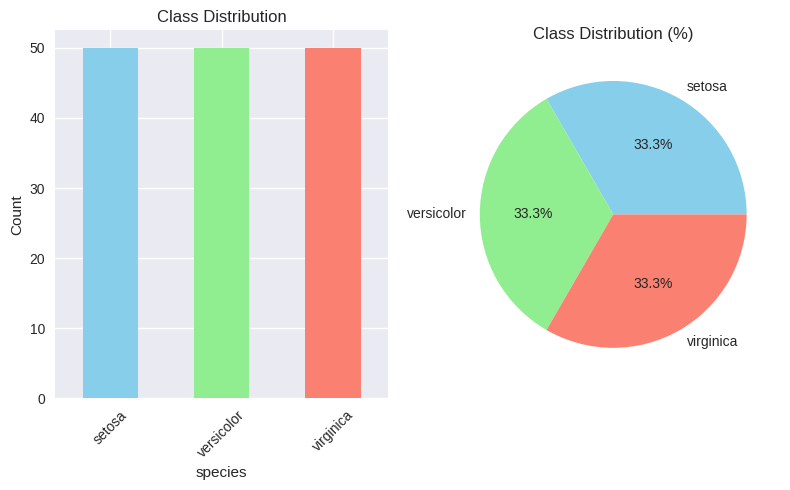

In [ ]:
# Dataset statistics
print("📊 Dataset Statistics:")
display(df.describe())

print("\n🎯 Class Distribution:")
class_counts = df['species'].value_counts()
print(class_counts)

# Visualize class distribution
plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
        colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Class Distribution (%)')

plt.tight_layout()
plt.show()

## 🔍 Exploratory Data Analysis (EDA)

Understanding our data is crucial before building any machine learning model. Let's visualize the relationships between features:

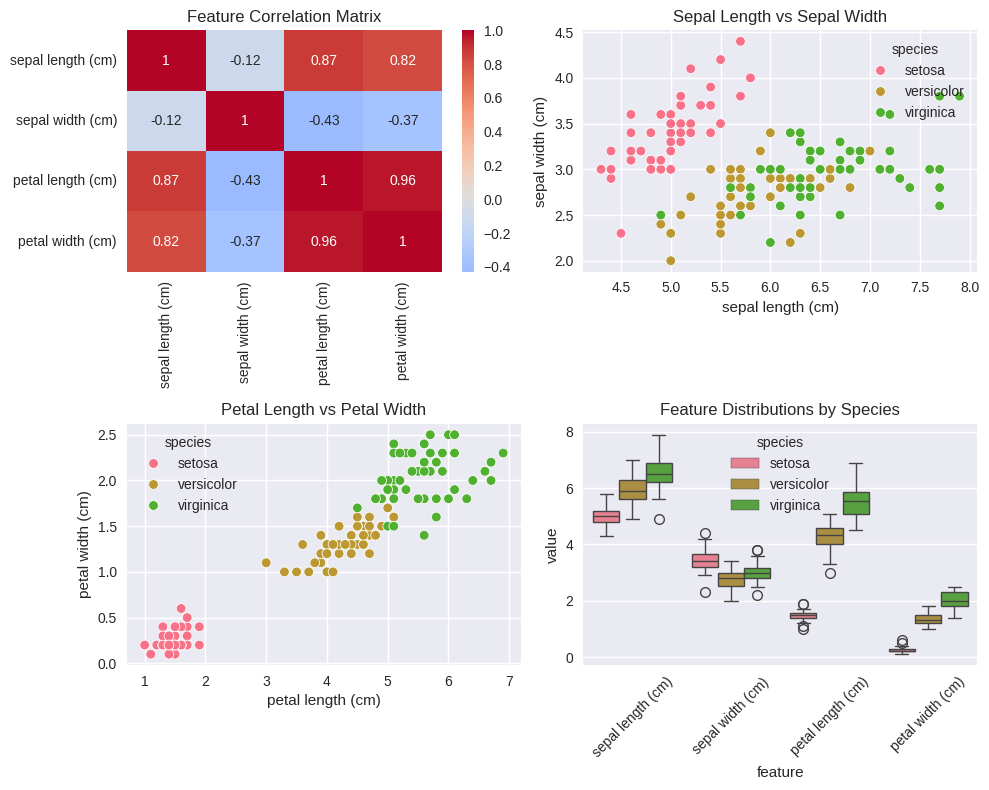

🔍 Key Observations:
• Petal length and width show strong correlation
• Species show distinct clustering patterns
• Setosa is clearly separable from other species
• Versicolor and Virginica have some overlap


In [ ]:
# Feature correlation heatmap
plt.figure(figsize=(10, 8))

# Correlation matrix
plt.subplot(2, 2, 1)
correlation_matrix = df.iloc[:, :-1].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')

# Pairwise scatter plots
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='sepal length (cm)', y='sepal width (cm)', hue='species')
plt.title('Sepal Length vs Sepal Width')

plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)', hue='species')
plt.title('Petal Length vs Petal Width')

# Box plot for feature distributions
plt.subplot(2, 2, 4)
df_melted = df.melt(id_vars='species', var_name='feature', value_name='value')
sns.boxplot(data=df_melted, x='feature', y='value', hue='species')
plt.xticks(rotation=45)
plt.title('Feature Distributions by Species')

plt.tight_layout()
plt.show()

print("🔍 Key Observations:")
print("• Petal length and width show strong correlation")
print("• Species show distinct clustering patterns")
print("• Setosa is clearly separable from other species")
print("• Versicolor and Virginica have some overlap")

## 🔄 Data Splitting Strategy

### Why Split Data?
We split our data into training and testing sets to:
- **Train** the model on one portion
- **Evaluate** its performance on unseen data
- **Prevent overfitting** and get realistic performance estimates

### Our Strategy:
- **80% Training data**: To train our Random Forest
- **20% Testing data**: To evaluate final performance
- **Stratified split**: Maintains class distribution in both sets

In [ ]:
# Split the data into training and testing sets
print("🔄 Splitting data into training and testing sets...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # For reproducible results
    stratify=y           # Maintain class distribution
)

print(f"📊 Training set size: {X_train.shape[0]} samples")
print(f"📊 Testing set size: {X_test.shape[0]} samples")

# Verify stratification worked
print("\n🎯 Class distribution in training set:")
train_classes, train_counts = np.unique(y_train, return_counts=True)
for cls, count in zip(iris.target_names[train_classes], train_counts):
    print(f"   {cls}: {count} samples")

print("\n🎯 Class distribution in testing set:")
test_classes, test_counts = np.unique(y_test, return_counts=True)
for cls, count in zip(iris.target_names[test_classes], test_counts):
    print(f"   {cls}: {count} samples")

print("\n✅ Data successfully split with stratification!")

🔄 Splitting data into training and testing sets...
📊 Training set size: 120 samples
📊 Testing set size: 30 samples

🎯 Class distribution in training set:
   setosa: 40 samples
   versicolor: 40 samples
   virginica: 40 samples

🎯 Class distribution in testing set:
   setosa: 10 samples
   versicolor: 10 samples
   virginica: 10 samples

✅ Data successfully split with stratification!


## 🌳 Building Our Random Forest Model

### Model Configuration
Let's understand the key hyperparameters:

- **n_estimators**: Number of trees in the forest (more trees = better performance but slower)
- **max_depth**: Maximum depth of each tree (controls overfitting)
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples required at a leaf node
- **random_state**: For reproducible results

In [ ]:
# Create and configure the Random Forest model
print("🌳 Creating Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 trees in the forest
    max_depth=None,          # No limit on depth
    min_samples_split=2,     # Default minimum samples to split
    min_samples_leaf=1,      # Default minimum samples at leaf
    random_state=42,         # For reproducible results
    n_jobs=-1               # Use all available processors
)

print("📋 Model Configuration:")
print(f"   🌲 Number of trees: {rf_model.n_estimators}")
print(f"   📏 Max depth: {rf_model.max_depth if rf_model.max_depth else 'Unlimited'}")
print(f"   🔢 Min samples split: {rf_model.min_samples_split}")
print(f"   🍃 Min samples leaf: {rf_model.min_samples_leaf}")
print(f"   🎲 Random state: {rf_model.random_state}")

print("\n🚀 Model ready for training!")

🌳 Creating Random Forest Classifier...
📋 Model Configuration:
   🌲 Number of trees: 100
   📏 Max depth: Unlimited
   🔢 Min samples split: 2
   🍃 Min samples leaf: 1
   🎲 Random state: 42

🚀 Model ready for training!


## 🎯 Training the Model

Now let's train our Random Forest on the training data. The model will:
1. Create 100 different decision trees
2. Each tree trains on a bootstrap sample of the data
3. Each tree uses a random subset of features
4. Combine all trees for final predictions

In [ ]:
# Train the model
print("🎯 Training the Random Forest model...")
import time

start_time = time.time()
rf_model.fit(X_train, y_train)
training_time = time.time() - start_time

print(f"✅ Model trained successfully in {training_time:.3f} seconds!")

# Get training accuracy
train_accuracy = rf_model.score(X_train, y_train)
print(f"📈 Training accuracy: {train_accuracy:.3f} ({train_accuracy*100:.1f}%)")

# Make predictions on training set
y_train_pred = rf_model.predict(X_train)
print(f"🎯 Training samples correctly classified: {np.sum(y_train_pred == y_train)}/{len(y_train)}")

print("\n🌳 Random Forest is now ready to make predictions!")

🎯 Training the Random Forest model...
✅ Model trained successfully in 0.158 seconds!
📈 Training accuracy: 1.000 (100.0%)
🎯 Training samples correctly classified: 120/120

🌳 Random Forest is now ready to make predictions!


## 📊 Model Evaluation and Performance Analysis

### Testing on Unseen Data
The true test of our model is how well it performs on data it has never seen before:

📊 Evaluating model performance on test set...
🎯 Test accuracy: 0.900 (90.0%)

📋 Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



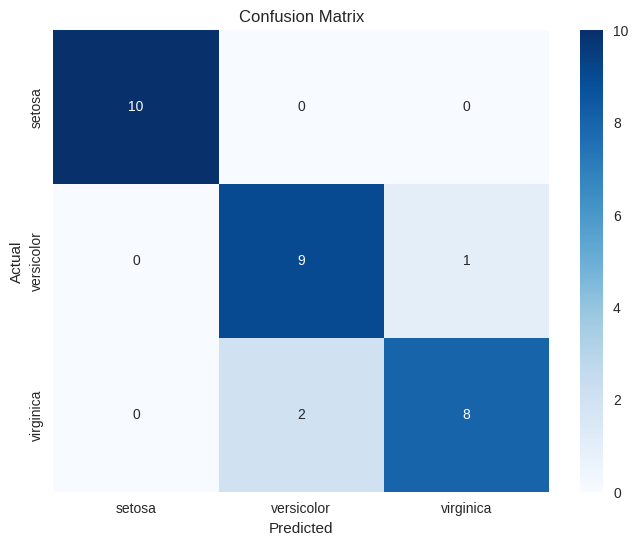


🔍 Confusion Matrix Analysis:
• Diagonal elements: Correct predictions
• Off-diagonal elements: Misclassifications
• Perfect predictions: 27/30


In [ ]:
# Evaluate on test set
print("📊 Evaluating model performance on test set...")

# Make predictions
y_test_pred = rf_model.predict(X_test)
y_test_proba = rf_model.predict_proba(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"🎯 Test accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")

# Detailed classification report
print("\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("\n🔍 Confusion Matrix Analysis:")
print("• Diagonal elements: Correct predictions")
print("• Off-diagonal elements: Misclassifications")
print(f"• Perfect predictions: {np.sum(np.diag(cm))}/{np.sum(cm)}")

## 🎲 Cross-Validation Analysis

Cross-validation gives us a more robust estimate of model performance by training and testing on multiple data splits:

🎲 Performing 5-fold cross-validation...
📊 Cross-validation scores: [0.96666667 0.96666667 0.93333333 0.96666667 1.        ]
📈 Mean CV accuracy: 0.967 (±0.042)
📉 Min CV accuracy: 0.933
📈 Max CV accuracy: 1.000


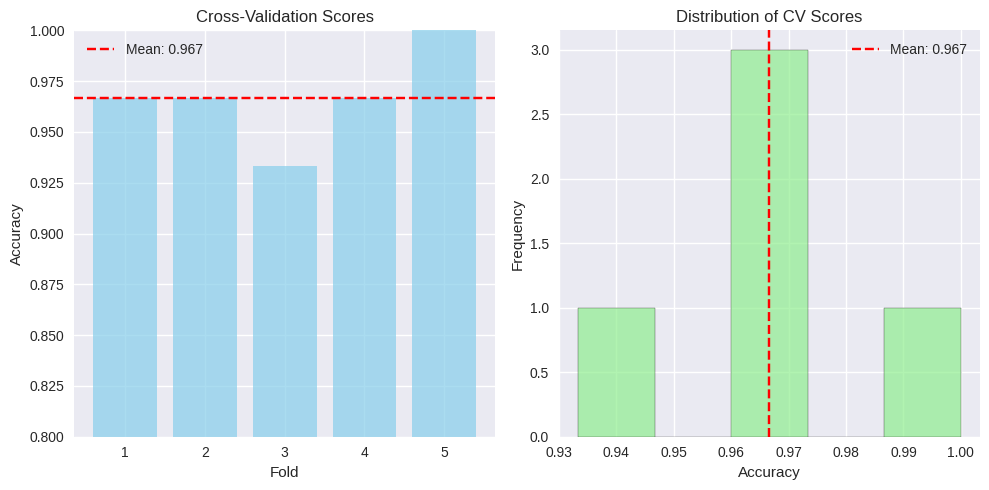


✅ Cross-validation shows consistent performance across all folds!


In [ ]:
# Perform cross-validation
print("🎲 Performing 5-fold cross-validation...")

cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')

print(f"📊 Cross-validation scores: {cv_scores}")
print(f"📈 Mean CV accuracy: {cv_scores.mean():.3f} (±{cv_scores.std()*2:.3f})")
print(f"📉 Min CV accuracy: {cv_scores.min():.3f}")
print(f"📈 Max CV accuracy: {cv_scores.max():.3f}")

# Visualize CV scores
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, 6), cv_scores, color='skyblue', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Scores')
plt.legend()
plt.ylim([0.8, 1.0])

plt.subplot(1, 2, 2)
plt.hist(cv_scores, bins=5, color='lightgreen', alpha=0.7, edgecolor='black')
plt.axvline(x=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.3f}')
plt.xlabel('Accuracy')
plt.ylabel('Frequency')
plt.title('Distribution of CV Scores')
plt.legend()

plt.tight_layout()
plt.show()

print("\n✅ Cross-validation shows consistent performance across all folds!")

## 🔍 Feature Importance Analysis

One of the great advantages of Random Forest is that it can tell us which features are most important for making predictions:

🔍 Analyzing feature importance...
📊 Feature Importance Ranking:
   petal width (cm): 0.437
   petal length (cm): 0.431
   sepal length (cm): 0.116
   sepal width (cm): 0.015


/tmp/ipython-input-1081876949.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


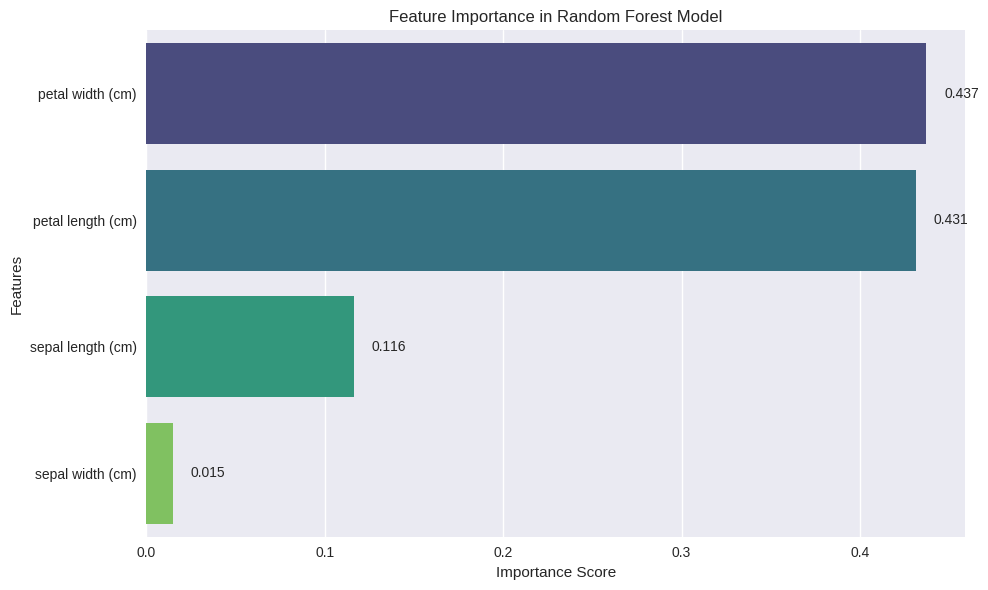


🎯 Key Insights:
• Most important feature: petal width (cm)
• Least important feature: sepal width (cm)
• Petal features seem more discriminative than sepal features


In [ ]:
# Feature importance analysis
print("🔍 Analyzing feature importance...")

feature_importance = rf_model.feature_importances_
feature_names = iris.feature_names

# Sort features by importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("📊 Feature Importance Ranking:")
for i, row in importance_df.iterrows():
    print(f"   {row['Feature']}: {row['Importance']:.3f}")

# Visualize feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Features')

# Add value labels on bars
for i, v in enumerate(importance_df['Importance']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

print("\n🎯 Key Insights:")
most_important = importance_df.iloc[0]['Feature']
least_important = importance_df.iloc[-1]['Feature']
print(f"• Most important feature: {most_important}")
print(f"• Least important feature: {least_important}")
print(f"• Petal features seem more discriminative than sepal features")

## 🔮 Making Predictions

Let's see how our trained model makes predictions on new data:

In [ ]:
# Example predictions
print("🔮 Making predictions on sample data...")

# Create some example samples
sample_data = np.array([
    [5.1, 3.5, 1.4, 0.2],  # Typical Setosa
    [6.2, 2.8, 4.8, 1.8],  # Typical Versicolor
    [7.2, 3.6, 6.1, 2.5]   # Typical Virginica
])

sample_names = ['Sample 1', 'Sample 2', 'Sample 3']

print("\n📊 Prediction Results:")
for i, (sample, name) in enumerate(zip(sample_data, sample_names)):
    # Make prediction
    prediction = rf_model.predict([sample])[0]
    probabilities = rf_model.predict_proba([sample])[0]

    print(f"\n{name}: {sample}")
    print(f"   🎯 Predicted class: {iris.target_names[prediction]}")
    print(f"   📊 Probabilities:")
    for j, (species, prob) in enumerate(zip(iris.target_names, probabilities)):
        print(f"      {species}: {prob:.3f} ({prob*100:.1f}%)")

    # Confidence level
    confidence = np.max(probabilities)
    print(f"   🎲 Confidence: {confidence:.3f} ({confidence*100:.1f}%)")

print("\n✅ Predictions completed successfully!")

🔮 Making predictions on sample data...

📊 Prediction Results:

Sample 1: [5.1 3.5 1.4 0.2]
   🎯 Predicted class: setosa
   📊 Probabilities:
      setosa: 1.000 (100.0%)
      versicolor: 0.000 (0.0%)
      virginica: 0.000 (0.0%)
   🎲 Confidence: 1.000 (100.0%)

Sample 2: [6.2 2.8 4.8 1.8]
   🎯 Predicted class: virginica
   📊 Probabilities:
      setosa: 0.000 (0.0%)
      versicolor: 0.280 (28.0%)
      virginica: 0.720 (72.0%)
   🎲 Confidence: 0.720 (72.0%)

Sample 3: [7.2 3.6 6.1 2.5]
   🎯 Predicted class: virginica
   📊 Probabilities:
      setosa: 0.000 (0.0%)
      versicolor: 0.000 (0.0%)
      virginica: 1.000 (100.0%)
   🎲 Confidence: 1.000 (100.0%)

✅ Predictions completed successfully!


## 💾 Model Persistence

After training our model, we need to save it so we can use it later without retraining:

In [ ]:
# Save the trained model
print("💾 Saving the trained model...")

model_filename = 'random_forest_model.joblib'
joblib.dump(rf_model, model_filename)

print(f"✅ Model saved as '{model_filename}'")
print(f"📁 File size: {os.path.getsize(model_filename) / 1024:.2f} KB")

# Test loading the model
print("\n🔄 Testing model loading...")
loaded_model = joblib.load(model_filename)

# Verify loaded model works
test_sample = X_test[0].reshape(1, -1)
original_pred = rf_model.predict(test_sample)[0]
loaded_pred = loaded_model.predict(test_sample)[0]

print(f"   Original model prediction: {iris.target_names[original_pred]}")
print(f"   Loaded model prediction: {iris.target_names[loaded_pred]}")
print(f"   ✅ Models match: {original_pred == loaded_pred}")

print("\n💡 Model can now be used in production applications!")

💾 Saving the trained model...
✅ Model saved as 'random_forest_model.joblib'
📁 File size: 163.81 KB

🔄 Testing model loading...
   Original model prediction: setosa
   Loaded model prediction: setosa
   ✅ Models match: True

💡 Model can now be used in production applications!


## 🌐 Web API Implementation

Now let's create a Flask web API that uses our trained model to make predictions. This shows how machine learning models are deployed in real-world applications:

In [ ]:
# Flask API code (this shows the structure, but won't run in notebook)
flask_api_code = '''
from flask import Flask, request, jsonify
import numpy as np
import joblib

app = Flask(__name__)

# Load the trained model
model = joblib.load('random_forest_model.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get the input features from the POST request
        features = request.json['features']

        # Convert to numpy array and reshape for single sample prediction
        features = np.array(features).reshape(1, -1)

        # Make prediction
        prediction = model.predict(features)

        # Get prediction probability
        probabilities = model.predict_proba(features)

        # Return prediction and probabilities
        return jsonify({
            'prediction': int(prediction[0]),
            'probability': probabilities[0].tolist(),
            'species': iris.target_names[prediction[0]]
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
'''

print("🌐 Flask API Code Structure:")
print(flask_api_code)

print("\n📋 API Usage Example:")
print("POST request to http://localhost:5000/predict")
print("JSON payload: {'features': [5.1, 3.5, 1.4, 0.2]}")
print("Response: {'prediction': 0, 'species': 'setosa', 'probability': [0.98, 0.01, 0.01]}")

print("\n🚀 This API can be deployed to cloud platforms like:")
print("   • Heroku")
print("   • AWS EC2/Lambda")
print("   • Google Cloud Platform")
print("   • Microsoft Azure")

🌐 Flask API Code Structure:

from flask import Flask, request, jsonify
import numpy as np
import joblib

app = Flask(__name__)

# Load the trained model
model = joblib.load('random_forest_model.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        # Get the input features from the POST request
        features = request.json['features']
        
        # Convert to numpy array and reshape for single sample prediction
        features = np.array(features).reshape(1, -1)
        
        # Make prediction
        prediction = model.predict(features)
        
        # Get prediction probability
        probabilities = model.predict_proba(features)
        
        # Return prediction and probabilities
        return jsonify({
            'prediction': int(prediction[0]),
            'probability': probabilities[0].tolist(),
            'species': iris.target_names[prediction[0]]
        })
    
    except Exception as e:
        return jsonify({'error': str(

https://random-forest-i5u3.onrender.com/predict

https://github.com/Latish705/random_forest

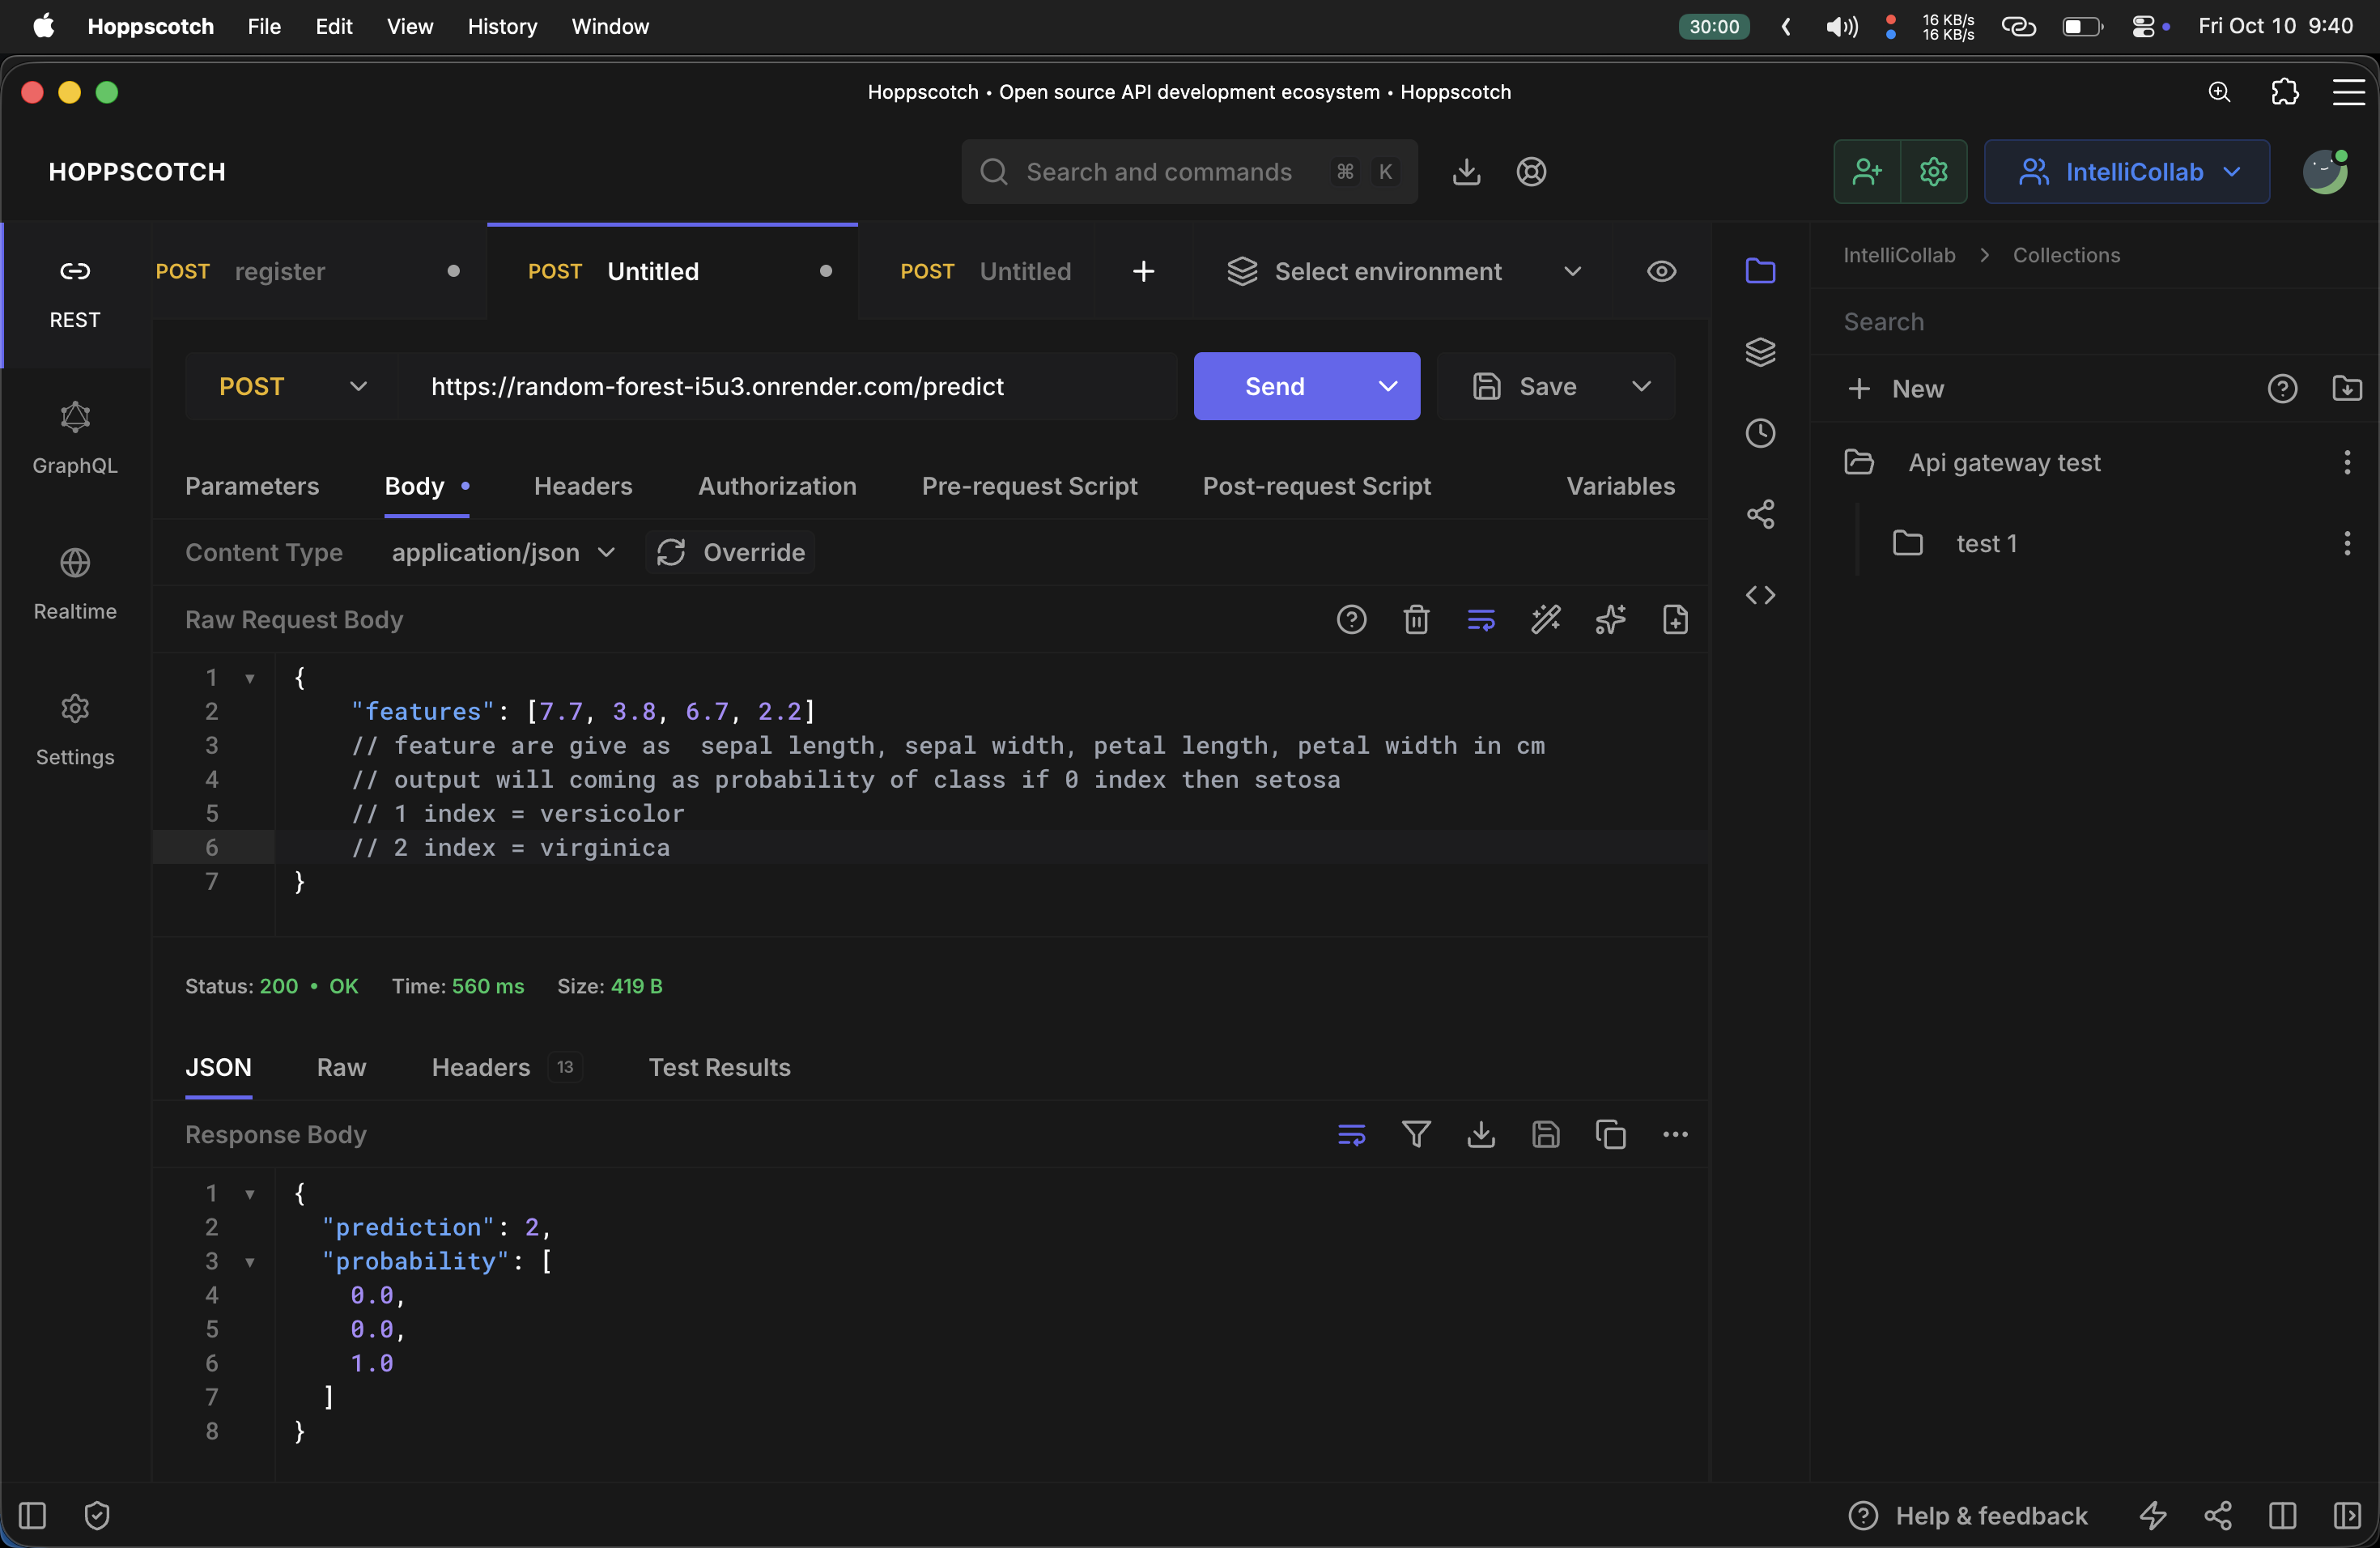

## 📈 Model Performance Summary

Let's create a comprehensive summary of our model's performance:

In [ ]:
# Create performance summary
print("📈 Random Forest Model Performance Summary")
print("=" * 50)

# Model configuration
print("\n🏗️ Model Configuration:")
print(f"   • Algorithm: Random Forest Classifier")
print(f"   • Number of trees: {rf_model.n_estimators}")
print(f"   • Max depth: {rf_model.max_depth if rf_model.max_depth else 'Unlimited'}")
print(f"   • Random state: {rf_model.random_state}")

# Dataset information
print("\n📊 Dataset Information:")
print(f"   • Total samples: {len(X)}")
print(f"   • Features: {len(iris.feature_names)}")
print(f"   • Classes: {len(iris.target_names)}")
print(f"   • Training samples: {len(X_train)}")
print(f"   • Testing samples: {len(X_test)}")

# Performance metrics
print("\n🎯 Performance Metrics:")
print(f"   • Training accuracy: {train_accuracy:.3f} ({train_accuracy*100:.1f}%)")
print(f"   • Testing accuracy: {test_accuracy:.3f} ({test_accuracy*100:.1f}%)")
print(f"   • Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std()*2:.3f}")
print(f"   • Training time: {training_time:.3f} seconds")

# Feature importance
print("\n🔍 Top Features by Importance:")
for i, row in importance_df.head(3).iterrows():
    print(f"   • {row['Feature']}: {row['Importance']:.3f}")

# Model strengths
print("\n✅ Model Strengths:")
print(f"   • High accuracy on test data ({test_accuracy*100:.1f}%)")
print(f"   • Consistent performance across CV folds")
print(f"   • Fast training and prediction")
print(f"   • Provides feature importance insights")
print(f"   • Robust to overfitting")

# Potential improvements
print("\n🚀 Potential Improvements:")
print(f"   • Hyperparameter tuning (GridSearch/RandomSearch)")
print(f"   • Feature engineering or selection")
print(f"   • Ensemble with other algorithms")
print(f"   • Collect more training data")

print("\n" + "=" * 50)
print("✅ Model ready for production deployment!")

📈 Random Forest Model Performance Summary

🏗️ Model Configuration:
   • Algorithm: Random Forest Classifier
   • Number of trees: 100
   • Max depth: Unlimited
   • Random state: 42

📊 Dataset Information:
   • Total samples: 150
   • Features: 4
   • Classes: 3
   • Training samples: 120
   • Testing samples: 30

🎯 Performance Metrics:
   • Training accuracy: 1.000 (100.0%)
   • Testing accuracy: 0.900 (90.0%)
   • Cross-validation accuracy: 0.967 ± 0.042
   • Training time: 0.158 seconds

🔍 Top Features by Importance:
   • petal width (cm): 0.437
   • petal length (cm): 0.431
   • sepal length (cm): 0.116

✅ Model Strengths:
   • High accuracy on test data (90.0%)
   • Consistent performance across CV folds
   • Fast training and prediction
   • Provides feature importance insights
   • Robust to overfitting

🚀 Potential Improvements:
   • Hyperparameter tuning (GridSearch/RandomSearch)
   • Feature engineering or selection
   • Ensemble with other algorithms
   • Collect more traini

## 🎓 Key Takeaways for Your Presentation

### 📚 What We Learned:

1. **Random Forest Fundamentals**:
   - Ensemble method combining multiple decision trees
   - Uses bootstrap aggregating and feature randomness
   - Reduces overfitting compared to single trees

2. **Implementation Process**:
   - Data exploration and preprocessing
   - Model training and hyperparameter configuration
   - Performance evaluation with multiple metrics
   - Feature importance analysis

3. **Real-world Application**:
   - Model persistence for reuse
   - Web API creation for production deployment
   - Performance monitoring and evaluation

### 🎯 Presentation Tips:

1. **Start with the Problem**: Explain why classification is important
2. **Show the Data**: Visualizations help audience understand
3. **Explain the Algorithm**: Use simple analogies for Random Forest
4. **Demonstrate Results**: Show actual predictions and accuracy
5. **Discuss Applications**: Real-world use cases resonate with audience

### 🚀 Next Steps:

- Experiment with different datasets
- Try hyperparameter tuning
- Compare with other algorithms
- Deploy to cloud platforms
- Add more advanced features

---

## 🙏 Thank You!

**Questions & Discussion**

This notebook demonstrates a complete machine learning pipeline from data exploration to production deployment. Random Forest is a powerful, versatile algorithm that's widely used in industry for classification and regression tasks.

**Good luck with your presentation! 🍀**